<a href="https://colab.research.google.com/github/a00377571/lsm-reconocimiento-mediapipe/blob/main/mano_uno_mediapipe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Instalación de Dependencias
Comenzamos instalando MediaPipe. También importaremos librerías adicionales que nos serán útiles como OpenCV (`cv2`), Matplotlib y NumPy.

In [30]:
# Reinstalamos de forma limpia para asegurar que los submódulos estén presentes
!pip uninstall -y mediapipe
!pip install mediapipe==0.10.14

Found existing installation: mediapipe 0.10.35
Uninstalling mediapipe-0.10.35:
  Successfully uninstalled mediapipe-0.10.35
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 29.8 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
ydf 0.12.0 requires protobuf<6.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.


In [1]:
import mediapipe as mp

# Si esta build no expone mp.solutions, lo “reconectamos” desde el submódulo real
if not hasattr(mp, "solutions"):
    from mediapipe.python import solutions as mp_solutions
    mp.solutions = mp_solutions

# Opcional: prueba rápida
print("mp version:", mp.__version__)
print("mp.solutions available:", hasattr(mp, "solutions"))

mp version: 0.10.14
mp.solutions available: True


In [2]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
import sys

print("MediaPipe version:", mp.__version__)
print("OpenCV version:", cv2.__version__)

MediaPipe version: 0.10.14
OpenCV version: 4.12.0


### 2. Función Auxiliar para Mostrar Imágenes
En entornos de Notebooks, la mejor manera de visualizar las imágenes procesadas por OpenCV es utilizando `matplotlib.pyplot`. Esta función se encarga de convertir el espacio de color de BGR a RGB y renderizar la imagen de forma correcta.

In [3]:
def mostrar_imagen(imagen, titulo="Imagen", tamaño=(8, 6)):
    """Muestra una imagen de OpenCV usando Matplotlib."""
    plt.figure(figsize=tamaño)
    # OpenCV usa BGR por defecto; lo convertimos a RGB para Matplotlib
    imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    plt.imshow(imagen_rgb)
    plt.title(titulo)
    plt.axis("off")
    plt.show()

### 3. Práctica 1: Detección de Manos (MediaPipe Hands)
En este ejemplo, descargaremos una imagen de prueba, utilizaremos el modelo `mp.solutions.hands` para procesar la imagen y extraeremos las coordenadas de los puntos clave (nudillos, puntas de los dedos, etc.) para dibujarlos sobre la foto.

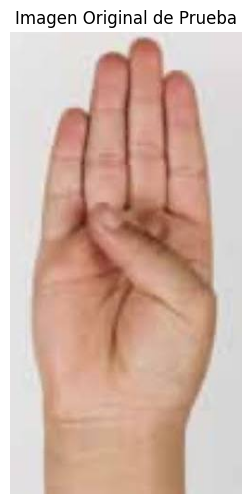

In [8]:
# Descargamos una imagen real de una mano desde un repositorio público
#!wget -q -O left_hand.jpg https://raw.githubusercontent.com/google/mediapipe/master/mediapipe/examples/desktop/hand_tracking/testdata/left_hand.jpg

# Cargamos la imagen
imagen_original = cv2.imread('mano_uno.jpg')

if imagen_original is None:
    print("Error: No se pudo cargar la imagen de prueba.")
else:
    mostrar_imagen(imagen_original, "Imagen Original de Prueba")

In [9]:
import mediapipe as mp
print("mediapipe file:", mp.__file__)
print("version:", getattr(mp, "__version__", "NO __version__"))
print("has solutions?:", hasattr(mp, "solutions"))
print("dir contains solutions?:", "solutions" in dir(mp))

mediapipe file: /usr/local/lib/python3.11/dist-packages/mediapipe/__init__.py
version: 0.10.14
has solutions?: True
dir contains solutions?: True


In [11]:
print(sys.version)

3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]


¡Se detectaron 1 mano(s)!


/usr/local/lib/python3.11/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


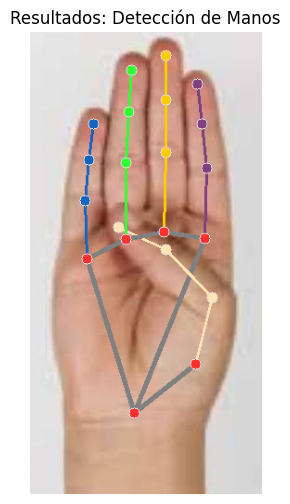

In [12]:
# Importamos directamente los submódulos de soluciones para evitar el AttributeError
from mediapipe.python.solutions import hands as mp_hands
from mediapipe.python.solutions import drawing_utils as mp_drawing
from mediapipe.python.solutions import drawing_styles as mp_drawing_styles

# Copiamos la imagen de base
imagen_dibujo = imagen_original.copy()

# Inicializamos el detector de manos
with mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=2,
    min_detection_confidence=0.5) as hands:

    # Convertimos a RGB para MediaPipe
    imagen_rgb = cv2.cvtColor(imagen_original, cv2.COLOR_BGR2RGB)

    # Procesamos la imagen
    resultados = hands.process(imagen_rgb)

    # Dibujamos los puntos si hay detección
    if resultados.multi_hand_landmarks:
        print(f"¡Se detectaron {len(resultados.multi_hand_landmarks)} mano(s)!")
        for hand_landmarks in resultados.multi_hand_landmarks:
            mp_drawing.draw_landmarks(
                imagen_dibujo,
                hand_landmarks,
                mp_hands.HAND_CONNECTIONS,
                mp_drawing_styles.get_default_hand_landmarks_style(),
                mp_drawing_styles.get_default_hand_connections_style()
            )
        mostrar_imagen(imagen_dibujo, "Resultados: Detección de Manos")
    else:
        print("No se detectaron manos en la imagen.")

Ahora que el modelo está funcionando, veamos qué tipo de datos genera por debajo MediaPipe.

Cuando procesas una imagen con MediaPipe Hands, obtienes un objeto que contiene una lista de puntos clave tridimensionales (X, Y, Z) para cada mano. Cada punto (o landmark) tiene:

x: Coordenada horizontal normalizada (entre 0.0 y 1.0 relativo al ancho de la imagen).
y: Coordenada vertical normalizada (entre 0.0 y 1.0 relativo al alto de la imagen).
z: La profundidad aproximada, teniendo como punto de referencia el plano de la muñeca.
Vamos a extraer y ver los datos numéricos reales de la muñeca (Wrist) y de las puntas de los dedos para entender cómo están representados.

### 4. Analizando los Datos Generados por MediaPipe
Cada mano contiene 21 puntos clave (landmarks). Vamos a imprimir la lista de puntos de la primera mano detectada, mostrando las coordenadas normalizadas y explicando cómo traducirlas a coordenadas reales en píxeles.

In [13]:
if resultados.multi_hand_landmarks:
    # Obtenemos los landmarks de la primera mano detectada
    primera_mano = resultados.multi_hand_landmarks[0]

    # Obtenemos las dimensiones de la imagen original para calcular píxeles reales
    alto, ancho, _ = imagen_original.shape

    print("=== INFORMACIÓN DE LA MANO DETECTADA ===\n")
    print(f"Total de puntos detectados: {len(primera_mano.landmark)}")

    # Mapeo de algunos puntos importantes usando mp_hands.HandLandmark
    puntos_clave = {
        "MUÑECA (WRIST)": mp_hands.HandLandmark.WRIST,
        "PUNTA DEL PULGAR (THUMB_TIP)": mp_hands.HandLandmark.THUMB_TIP,
        "PUNTA DEL ÍNDICE (INDEX_FINGER_TIP)": mp_hands.HandLandmark.INDEX_FINGER_TIP,
        "PUNTA DEL MEDIO (MIDDLE_FINGER_TIP)": mp_hands.HandLandmark.MIDDLE_FINGER_TIP
    }

    for nombre, enum_punto in puntos_clave.items():
        landmark = primera_mano.landmark[enum_punto]
        # Conversión de coordenadas normalizadas a píxeles en la imagen original
        px_x = int(landmark.x * ancho)
        px_y = int(landmark.y * alto)

        print(f"{nombre}:")
        print(f"  -> Coordenadas Normalizadas: (x: {landmark.x:.4f}, y: {landmark.y:.4f}, z: {landmark.z:.4f})")
        print(f"  -> Posición Real en la Imagen: (X: {px_x}px, Y: {px_y}px)\n")
else:
    print("Primero debes ejecutar la celda anterior para que existan 'resultados'.")

=== INFORMACIÓN DE LA MANO DETECTADA ===

Total de puntos detectados: 21
MUÑECA (WRIST):
  -> Coordenadas Normalizadas: (x: 0.4483, y: 0.8244, z: 0.0000)
  -> Posición Real en la Imagen: (X: 112px, Y: 412px)

PUNTA DEL PULGAR (THUMB_TIP):
  -> Coordenadas Normalizadas: (x: 0.3839, y: 0.4230, z: -0.1465)
  -> Posición Real en la Imagen: (X: 95px, Y: 211px)

PUNTA DEL ÍNDICE (INDEX_FINGER_TIP):
  -> Coordenadas Normalizadas: (x: 0.7207, y: 0.1139, z: -0.1709)
  -> Posición Real en la Imagen: (X: 180px, Y: 56px)

PUNTA DEL MEDIO (MIDDLE_FINGER_TIP):
  -> Coordenadas Normalizadas: (x: 0.5860, y: 0.0505, z: -0.1862)
  -> Posición Real en la Imagen: (X: 146px, Y: 25px)



Bien pero ahora quiero exportar estos datos a cvs

¡Excelente idea! Para que puedas trabajar con esta información o usarla para entrenar tus propios modelos, podemos estructurar los 21 puntos clave de la mano en un DataFrame de pandas y exportarlo a un archivo CSV.


Crearemos una tabla con las siguientes columnas:
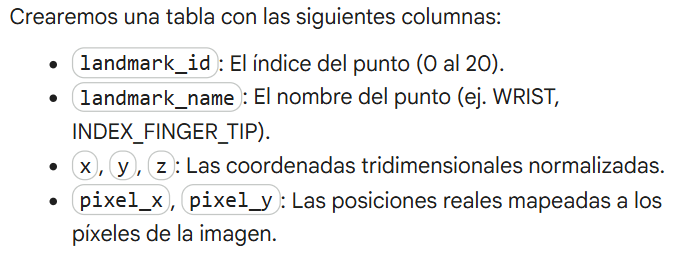

landmark_id: El índice del punto (0 al 20).
landmark_name: El nombre del punto (ej. WRIST, INDEX_FINGER_TIP).
x, y, z: Las coordenadas tridimensionales normalizadas.
pixel_x, pixel_y: Las posiciones reales mapeadas a los píxeles de la imagen.
Aquí tienes el código para generar y descargar ese archivo CSV:

### 5. Exportar los Landmarks de la Mano a un Archivo CSV
Vamos a mapear los 21 puntos clave usando la biblioteca `pandas`, guardarlos en un archivo llamado `landmarks_mano.csv` y mostrar una vista previa de la estructura generada.

In [18]:
import pandas as pd

if resultados.multi_hand_landmarks:
    primera_mano = resultados.multi_hand_landmarks[0]
    alto, ancho, _ = imagen_original.shape

    datos_landmarks = []

    # Recorremos los 21 landmarks oficiales de MediaPipe Hands
    for idx, landmark in enumerate(primera_mano.landmark):
        # Obtener el nombre del landmark desde el enum de MediaPipe
        nombre_landmark = mp_hands.HandLandmark(idx).name

        # Convertir a coordenadas de píxeles
        px_x = int(landmark.x * ancho)
        px_y = int(landmark.y * alto)

        # Guardar en nuestra lista de datos
        datos_landmarks.append({
            "landmark_id": idx,
            "landmark_name": nombre_landmark,
            "x": landmark.x,
            "y": landmark.y,
            "z": landmark.z,
            "pixel_x": px_x,
            "pixel_y": px_y
        })

    # Crear el DataFrame
    df_landmarks = pd.DataFrame(datos_landmarks)

    # Exportar a CSV
    df_landmarks.to_csv('landmarks_mano.csv', index=False)
    print("¡Archivo 'landmarks_mano.csv' guardado correctamente!\n")

    # Mostrar los primeros registros de la tabla
    display(df_landmarks.head(20))
else:
    print("No hay landmarks detectados para exportar.")

¡Archivo 'landmarks_mano.csv' guardado correctamente!



,landmark_id,landmark_name,x,y,z,pixel_x,pixel_y
0,0,WRIST,0.448317,0.824390,0.000001,112,412
1,1,THUMB_CMC,0.713683,0.719530,-0.096023,178,359
2,2,THUMB_MCP,0.785797,0.574493,-0.115622,196,287
3,3,THUMB_IP,0.586459,0.470221,-0.130794,146,235
4,4,THUMB_TIP,0.383862,0.422969,-0.146493,95,211
5,5,INDEX_FINGER_MCP,0.755355,0.447951,-0.002028,188,223
6,6,INDEX_FINGER_PIP,0.761508,0.295401,-0.059199,190,147
7,7,INDEX_FINGER_DIP,0.742168,0.198670,-0.121095,185,99
8,8,INDEX_FINGER_TIP,0.720734,0.113918,-0.170875,180,56
9,9,MIDDLE_FINGER_MCP,0.576053,0.432178,-0.013970,144,216
